In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

In [2]:
df=pd.read_csv("height-weight.csv")
df.head()

,Height,Weight
0,175.7,72.8
1,183.2,78.9
2,184.2,86.2
3,191.2,90.4
4,185.0,79.5


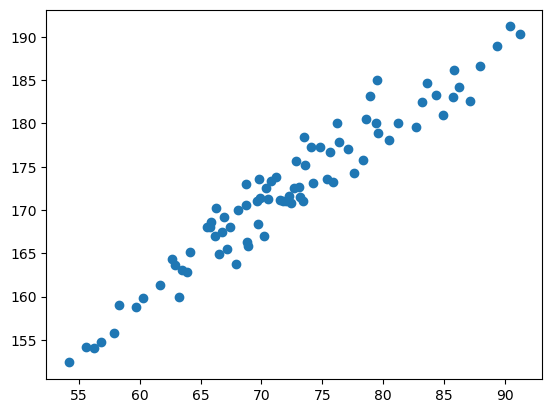

In [3]:
plt.scatter(df['Weight'],df['Height'])

In [4]:
# divide the dataset into dependent and independent feature
X=df[['Weight']]  ## independent
y=df['Height']  ## dependent

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42)

In [7]:
X.shape,X_train.shape

((83, 1), (66, 1))

In [8]:
## Standardize dataset Train independent data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

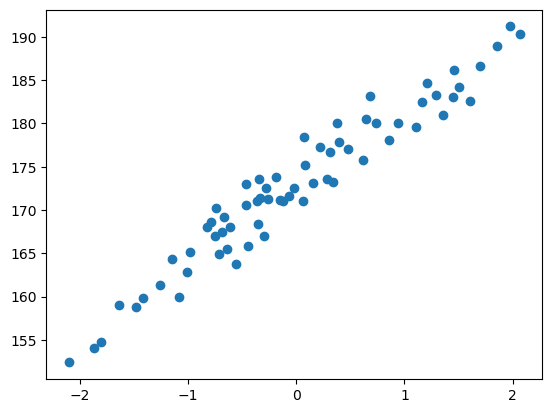

In [10]:
plt.scatter(X_train_scaled,y_train)

#### ***Train our model***

In [11]:
from sklearn.linear_model import LinearRegression
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
Slope,Intercept=linreg.coef_,linreg.intercept_

In [13]:
print("Slope of weight is : ",Slope)
print("Intercept of the weight is : ",Intercept)

Slope of weight is :  [8.57438944]
Intercept of the weight is :  172.8136363636364


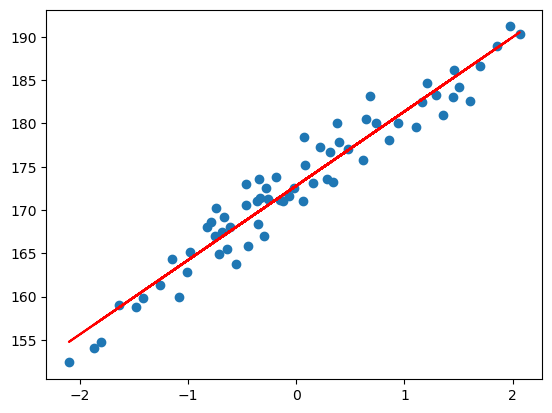

In [14]:
y_pred = linreg.predict(X_train_scaled)
plt.scatter(X_train_scaled,y_train)
plt.plot(X_train_scaled,y_pred,color="red")

In [15]:
y_pred_test=linreg.predict(X_test_scaled)

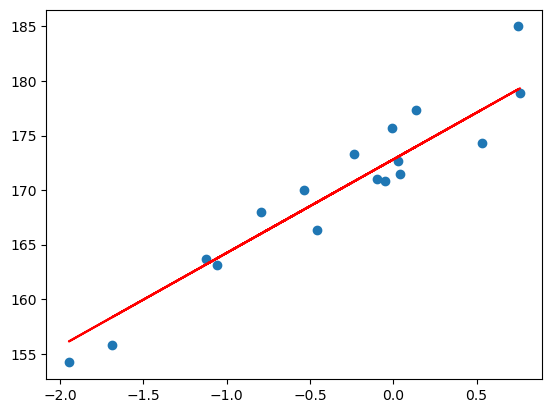

In [16]:
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled,y_pred_test,color="red")

In [17]:
## Performance metrics
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mae=mean_absolute_error(y_test,y_pred_test)
mse=mean_squared_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mae)
print(mse)
print(rmse)

2.034247633325835
5.871889435269189
2.4231981832423837


In [18]:
score=r2_score(y_test,y_pred_test)
print(score)

0.8988292135042075


In [19]:
print("Adjusted r2_score : ",1- (1-score)*(len(y_test)-1)/(len(y_test) - X_test_scaled.shape[1] - 1))

Adjusted r2_score :  0.892084494404488


In [20]:
scaled_weight=scaler.transform([[25.8]])
scaled_weight

d:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-5.30516937]])

In [21]:
linreg.predict(scaled_weight)

array([127.3250481])

In [22]:
residuals=y_test-y_pred_test
residuals

30   -2.585995
0     2.947870
22   -1.927751
31   -0.663367
18    1.790578
28   -2.550778
10    3.291377
53   -1.638743
4     5.772095
12   -1.565516
49   -0.978903
33   -3.091491
69    2.013606
35    2.480938
70    0.516553
45   -0.342090
75   -0.424558
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

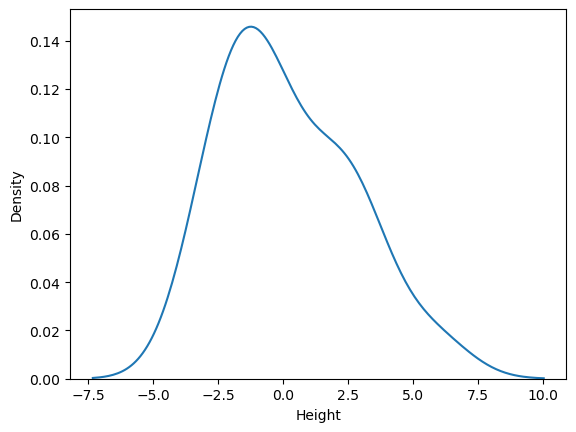

In [28]:
sns.kdeplot(residuals)

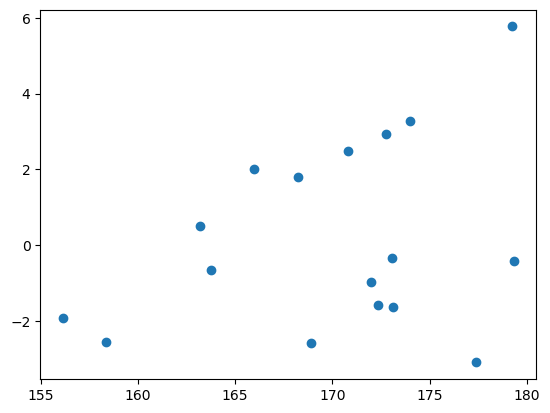

In [24]:
plt.scatter(y_pred_test,residuals)